In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
import itertools
import warnings
warnings.filterwarnings('ignore')
print('Imports OK')


Imports OK


## Long-Horizon WAC Price Regressor
> **Key difference from `Tree_based_modeling.ipynb`**: `PREV_PERIOD_BASELINE_WAC_PRICE` is **dropped** from features.
> The model predicts T+1 WAC using only the current period's recorded WAC and structural features.
> This simulates a scenario where we score the entire validation set in one batch without relying on the previous period's price.
> Validation set (2024) is scored in one shot — no recursive feeding of predictions.

In [2]:
df = pd.read_csv('~/PycharmProjects/JupyterProject/data/real_data/No_leakage_Active_COPA_data.csv')
df['WAC_PRICE_COPA_DATE'] = pd.to_datetime(df['WAC_PRICE_COPA_DATE'])

# Keep only materials with >= 2 years of history before the validation cutoff
cutoff_date    = pd.Timestamp('2024-01-01')
min_hist_date  = cutoff_date - pd.DateOffset(years=2)
items_with_history = (
    df[df['WAC_PRICE_COPA_DATE'] < cutoff_date]
    .groupby('COPA_MTRL_NUM')['WAC_PRICE_COPA_DATE']
    .min()
    .loc[lambda x: x <= min_hist_date]
    .index
)
df = df[df['COPA_MTRL_NUM'].isin(items_with_history)]
df = df.sort_values(['COPA_MTRL_NUM', 'WAC_PRICE_COPA_DATE'])

# Drop low-end outliers
before = len(df)
df = df[df['BASELINE_WAC_PRICE'] >= 1].copy()
print(f'Dropped {before - len(df):,} rows with BASELINE_WAC_PRICE < $1')

# Join LOE expiry year via SELL_DSCR substring match on Product Family
loe_xl   = pd.read_excel('~/PycharmProjects/JupyterProject/data/real_data/Top_500_Revenue_Materials_BT_05292026_v1.xlsx',
                          sheet_name='LOE_Data')
loe_valid = (
    loe_xl[loe_xl['LOE/Biosim on market'].notna()]
    [['Product Family','LOE/Biosim on market']]
    .rename(columns={'LOE/Biosim on market': 'LOE_YEAR'})
    .drop_duplicates('Product Family')
    .sort_values('Product Family', key=lambda s: s.str.len(), ascending=False)  # match longer names first
)
sell_upper = df['SELL_DSCR'].str.upper().fillna('')
loe_series = pd.Series(-1.0, index=df.index, dtype=float)
for _, row in loe_valid.iterrows():
    family = str(row['Product Family']).upper()
    mask = sell_upper.str.contains(family, regex=False) & (loe_series == -1)
    loe_series[mask] = row['LOE_YEAR']
df['LOE_YEAR'] = loe_series
loe_matched = df['LOE_YEAR'].ne(-1).mean()
print(f'LOE year matched: {loe_matched*100:.1f}% of rows  ({df["LOE_YEAR"].ne(-1).sum():,} rows)')

# Join THERAPEUTIC_CLASS and MANUFACTURER_NAME from baseline model input
bmi = pd.read_csv('~/PycharmProjects/JupyterProject/data/real_data/Baseline_model_input.csv',
                  dtype={'MTRL_NUM': str})
bmi['MTRL_NUM'] = bmi['MTRL_NUM'].str.zfill(18)
bmi_lookup = (bmi[['MTRL_NUM','THERAPEUTIC_CLASS','MANUFACTURER_NAME']]
              .drop_duplicates('MTRL_NUM')
              .rename(columns={'MTRL_NUM': 'COPA_MTRL_NUM'}))
df['COPA_MTRL_NUM'] = df['COPA_MTRL_NUM'].astype(str).str.zfill(18)
df = df.merge(bmi_lookup, on='COPA_MTRL_NUM', how='left')
df['THERAPEUTIC_CLASS']  = df['THERAPEUTIC_CLASS'].fillna(-1)
df['MANUFACTURER_NAME']  = df['MANUFACTURER_NAME'].fillna('Unknown')
matched = df['THERAPEUTIC_CLASS'].ne(-1).mean()
print(f'Remaining: {len(df):,} rows, {df["COPA_MTRL_NUM"].nunique():,} materials')
print(f'Therapeutic class / manufacturer matched: {matched*100:.1f}% of rows')


Dropped 1,075 rows with BASELINE_WAC_PRICE < $1
LOE year matched: 5.2% of rows  (11,058 rows)
Remaining: 213,660 rows, 4,281 materials
Therapeutic class / manufacturer matched: 96.3% of rows


In [3]:
# ── Price-history feature engineering (all backward-looking, no leakage) ──
import numpy as np

df = df.sort_values(['COPA_MTRL_NUM', 'WAC_PRICE_COPA_DATE']).reset_index(drop=True)

# ── Helper: binary flag for each row where price changed from prior month ──
df['_price_changed'] = (
    df.groupby('COPA_MTRL_NUM')['BASELINE_WAC_PRICE']
    .transform(lambda x: (x != x.shift(1)).astype(int))
)
# First row per material has no prior period — treat as no change
first_idx = df.groupby('COPA_MTRL_NUM').head(1).index
df.loc[first_idx, '_price_changed'] = 0

# ── 1. time_since_last_increase: months since the last WAC change ──
def _time_since_change(x):
    out, count = [], 0
    for changed in x:
        if changed:
            count = 0
        out.append(count)
        count += 1
    return pd.Series(out, index=x.index)

df['time_since_last_increase'] = (
    df.groupby('COPA_MTRL_NUM')['_price_changed'].transform(_time_since_change)
)

# ── 2. num_increases_last_24m ──
df['num_increases_last_24m'] = (
    df.groupby('COPA_MTRL_NUM')['_price_changed']
    .transform(lambda x: x.rolling(24, min_periods=1).sum())
)

# ── 3. increase_spell_length: consecutive months at current price ──
def _spell_length(x):
    out, count, prev = [], 1, None
    for v in x:
        if v == prev:
            count += 1
        else:
            count = 1
        out.append(count)
        prev = v
    return pd.Series(out, index=x.index)

df['increase_spell_length'] = (
    df.groupby('COPA_MTRL_NUM')['BASELINE_WAC_PRICE'].transform(_spell_length)
)

# ── 4. jan_jul_indicator ──
df['month'] = df['WAC_PRICE_COPA_DATE'].dt.month
df['jan_jul_indicator'] = df['month'].isin([1, 7]).astype(int)

# ── 5. Monthly pct change (basis for several rolling features) ──
df['_monthly_pct_chg'] = (
    df.groupby('COPA_MTRL_NUM')['BASELINE_WAC_PRICE']
    .transform(lambda x: x.pct_change().clip(-1, 10))
    .fillna(0)
)

# ── 6. prior_pct_increase: % magnitude of the most recent actual price change ──
def _prior_pct_inc(x):
    """For each row, return the % change at the last actual price increase."""
    out, last_pct = [], 0.0
    for pct, changed in zip(x['_monthly_pct_chg'], x['_price_changed']):
        if changed:
            last_pct = pct
        out.append(last_pct)
    return pd.Series(out, index=x.index)

df['prior_pct_increase'] = (
    df.groupby('COPA_MTRL_NUM')[['_monthly_pct_chg','_price_changed']]
    .apply(_prior_pct_inc)
    .reset_index(level=0, drop=True)
)

# ── 7. rolling_avg_increase_36m ──
df['rolling_avg_increase_36m'] = (
    df.groupby('COPA_MTRL_NUM')['_monthly_pct_chg']
    .transform(lambda x: x.rolling(36, min_periods=6).mean())
    .fillna(0)
)

# ── 8. max_increase_last_3yrs ──
df['max_increase_last_3yrs'] = (
    df.groupby('COPA_MTRL_NUM')['_monthly_pct_chg']
    .transform(lambda x: x.rolling(36, min_periods=6).max())
    .fillna(0)
)

# ── 9. compound_increase_rate: annualised 3-yr CAGR ──
df['_price_36m_ago'] = (
    df.groupby('COPA_MTRL_NUM')['BASELINE_WAC_PRICE'].transform(lambda x: x.shift(36))
)
df['compound_increase_rate'] = (
    (df['BASELINE_WAC_PRICE'] / df['_price_36m_ago'].replace(0, np.nan)) ** (1/3) - 1
).fillna(0).clip(-1, 5)

# ── 10. has_increased_every_year_last_3yrs ──
df['_year'] = df['WAC_PRICE_COPA_DATE'].dt.year
yr_change = (
    df[df['_price_changed'] == 1]
    .groupby(['COPA_MTRL_NUM','_year']).size()
    .gt(0).astype(int).reset_index(name='_had_change')
)
yr_dict = yr_change.set_index(['COPA_MTRL_NUM','_year'])['_had_change'].to_dict()

def _every_year_3yr(group):
    mtrl = group['COPA_MTRL_NUM'].iloc[0]
    result = []
    for yr in group['_year']:
        flag = all(yr_dict.get((mtrl, yr - k), 0) == 1 for k in range(1, 4))
        result.append(int(flag))
    return pd.Series(result, index=group.index)

df['has_increased_every_year_last_3yrs'] = (
    df.groupby('COPA_MTRL_NUM')[['COPA_MTRL_NUM','_year']]
    .apply(_every_year_3yr)
    .reset_index(level=0, drop=True)
)

# ── 11. increase_volatility_low_flag ──
df['_inc_vol'] = (
    df.groupby('COPA_MTRL_NUM')['_monthly_pct_chg']
    .transform(lambda x: x.rolling(36, min_periods=6).std())
    .fillna(0)
)
df['increase_volatility_low_flag'] = (df['_inc_vol'] < 0.005).astype(int)

# ── Drop temp columns (prefixed with _) ──
temp_cols = [c for c in df.columns if c.startswith('_')]
df.drop(columns=temp_cols, inplace=True)

new_feats = ['time_since_last_increase','num_increases_last_24m','increase_spell_length',
             'jan_jul_indicator','month','prior_pct_increase','rolling_avg_increase_36m',
             'max_increase_last_3yrs','compound_increase_rate',
             'has_increased_every_year_last_3yrs','increase_volatility_low_flag']
print(f'New features added: {len(new_feats)}')
print(df[new_feats].describe().round(4).to_string())


New features added: 11
       time_since_last_increase  num_increases_last_24m  increase_spell_length  jan_jul_indicator        month  prior_pct_increase  rolling_avg_increase_36m  max_increase_last_3yrs  compound_increase_rate  has_increased_every_year_last_3yrs  increase_volatility_low_flag
count               213660.0000             213660.0000            213660.0000        213660.0000  213660.0000         213660.0000               213660.0000             213660.0000             213660.0000                         213660.0000                   213660.0000
mean                    11.6561                  2.3206                12.6561             0.1710       6.1629              0.0162                    0.0022                  0.0433                  0.0067                              0.1264                        0.4497
std                     12.9871                  3.4011                12.9871             0.3765       3.4673              0.1009                    0.0062        

In [4]:
# ── CMS Part B/D Spending Features (optional — delete this cell to roll back) ──
# Fetches 5-yr CAGR and YoY price change from Medicare Part B and Part D spending data.
# Joined to df via SELL_DSCR substring match on CMS brand name (longest-first to avoid partial matches).
# Unmatched drugs filled with 0 (semantically correct: no Medicare spending signal).
# import requests

# def fetch_cms_all(dataset_id, label):
#     rows, offset = [], 0
#     while True:
#         r = requests.get(
#             f"https://data.cms.gov/data-api/v1/dataset/{dataset_id}/data",
#             params={"filter[Mftr_Name]": "Overall", "size": 2000, "offset": offset},
#             timeout=30
#         )
#         batch = r.json()
#         if not batch:
#             break
#         rows.extend(batch)
#         offset += 2000
#         if len(batch) < 2000:
#             break
#     print(f"{label}: {len(rows):,} rows")
#     return pd.DataFrame(rows)

# partd = fetch_cms_all("7e0b4365-fd63-4a29-8f5e-e0ac9f66a81b", "Part D")
# partb = fetch_cms_all("76a714ad-3a2c-43ac-b76d-9dadf8f7d890", "Part B")

# Rename to common column names (Part B has extra 'n' in YoY column name)
# partd_feat = partd[["Brnd_Name", "CAGR_Avg_Spnd_Per_Dsg_Unt_19_23", "Chg_Avg_Spnd_Per_Dsg_Unt_22_23", "Tot_Spndng_2023"]].copy()
# partd_feat.columns = ["Brnd_Name", "cms_cagr_19_23", "cms_yoy_22_23", "cms_tot_spend_2023"]
# partd_feat["cms_source"] = "partd"

# partb_feat = partb[["Brnd_Name", "CAGR_Avg_Spnd_Per_Dsg_Unt_19_23", "Chg_Avg_Spndng_Per_Dsg_Unt_22_23", "Tot_Spndng_2023"]].copy()
# partb_feat.columns = ["Brnd_Name", "cms_cagr_19_23", "cms_yoy_22_23", "cms_tot_spend_2023"]
# partb_feat["cms_source"] = "partb"

# For drugs in both, prefer Part D (pharmacy-dispensed closer to commercial WAC)
# cms = pd.concat([partd_feat, partb_feat]).drop_duplicates(subset="Brnd_Name", keep="first")
# cms[["cms_cagr_19_23", "cms_yoy_22_23", "cms_tot_spend_2023"]] = (
#     cms[["cms_cagr_19_23", "cms_yoy_22_23", "cms_tot_spend_2023"]].apply(pd.to_numeric, errors="coerce")
# )

# Build lookup dict keyed on uppercase brand name
# brand_lookup = {
#     row["Brnd_Name"].upper(): row
#     for _, row in cms.iterrows()
#     if pd.notna(row["Brnd_Name"])
# }

# Substring match: longest CMS brand name first to avoid partial matches
# brands_sorted = sorted(brand_lookup.keys(), key=len, reverse=True)
# unique_dscrips = df["SELL_DSCR"].str.upper().fillna("").unique()
# dscr_to_brand = {}
# for brand in brands_sorted:
#     for dscr in unique_dscrips:
#         if brand in dscr and dscr not in dscr_to_brand:
#             dscr_to_brand[dscr] = brand

# df["_dscr_upper"] = df["SELL_DSCR"].str.upper().fillna("")
# df["_cms_brand"]  = df["_dscr_upper"].map(dscr_to_brand)

# for col in ["cms_cagr_19_23", "cms_yoy_22_23", "cms_tot_spend_2023"]:
#     df[col] = df["_cms_brand"].map(lambda b: brand_lookup[b][col] if pd.notna(b) else np.nan)
#     df[col] = df[col].fillna(0.0)

# df.drop(columns=["_dscr_upper", "_cms_brand"], inplace=True)

# matched = (df["cms_cagr_19_23"] != 0).sum()
# print(f"Rows with CMS data: {matched:,} / {len(df):,} ({100*matched/len(df):.1f}%)")
# print(f"New features: cms_cagr_19_23, cms_yoy_22_23, cms_tot_spend_2023")
# print(df[["cms_cagr_19_23", "cms_yoy_22_23", "cms_tot_spend_2023"]].describe().round(4))


In [5]:
# ── Regression target: next month's WAC price ──
# Computed on full df before splitting — shift(-1) looks at T+1 within each material
df['TGT_NEXT_MONTH_WAC'] = (
    df.groupby('COPA_MTRL_NUM')['BASELINE_WAC_PRICE'].shift(-1)
)

# Train: pre-2024  |  Validation: all of 2024  (scored in one batch)
reg_train_full = df[df['WAC_PRICE_COPA_DATE'] < '2024-01-01'].copy()
reg_val_full   = df[
    (df['WAC_PRICE_COPA_DATE'] >= '2024-01-01') &
    (df['WAC_PRICE_COPA_DATE'] <  '2025-01-01')
].copy()

reg_train = reg_train_full.dropna(subset=['TGT_NEXT_MONTH_WAC']).copy()
reg_val   = reg_val_full.dropna(subset=['TGT_NEXT_MONTH_WAC']).copy()
print(f'Train rows: {len(reg_train):,}  |  Val rows: {len(reg_val):,}')


Train rows: 99,165  |  Val rows: 48,207


In [6]:
# ── Feature prep — PREV_PERIOD_BASELINE_WAC_PRICE intentionally excluded ──
# This is the long-horizon setup: we only use the current period's actual recorded WAC
# plus structural/behavioural features. No previous-period price lag.
reg_cols_to_drop = [
    'TGT_NEXT_MONTH_WAC',
    'TGT_CHANGE_UPCOMING_MNTH',
    'WAC_PRICE_COPA_DATE',
    'IS_FUTURE_PERIOD_FLAG',
    'COPA_NDC_NUM', 'COPA_MTRL_NUM',
    'SNW_NDC_NUM',  'SNW_MTRL_NUM',
    'SNW_LAST_EFF_DATE',
    'COPA_WAC_PRICE', 'SNW_WAC_PRICE',
    'COPA_SNW_WAC_PRICE_MATCH_IND',
    'PREFERRED_SOURCE', 'EFFECTIVE_SOURCE',
    'SELL_DSCR',
    # THERAPEUTIC_CLASS and MANUFACTURER_NAME are kept — joined from Baseline_model_input.csv
    'PREV_PERIOD_COPA_WAC_PRICE',
    'PREV_PERIOD_SNW_WAC_PRICE',
    # ↓ KEY DIFFERENCE: drop previous period baseline WAC price
    'PREV_PERIOD_BASELINE_WAC_PRICE',
    'BASELINE_MOM_VAR_PCT',   # derived from prev period price — also unavailable
]

X_train = reg_train.drop(reg_cols_to_drop, axis=1, errors='ignore')
X_val   = reg_val.drop(reg_cols_to_drop, axis=1, errors='ignore')
y_train = reg_train['TGT_NEXT_MONTH_WAC']
y_val   = reg_val['TGT_NEXT_MONTH_WAC']

print(f'Features used: {X_train.shape[1]}')
print(X_train.columns.tolist())


Features used: 29
['COPA_FISCAL_YEAR_PERIOD', 'CUST_PROD_CATEGORY', 'SNW_FIRST_EFF_DATE', 'SNW_PRC_EFF_DT', 'NET_REVENUE', 'COPA_MOM_VAR_PCT', 'SNW_MOM_VAR_PCT', 'AVG_COPA_VARIANCE', 'AVG_SNW_VARIANCE', 'SNW_NULL_MONTHS_ROLLING', 'TOTAL_MONTHS_ROLLING', 'BASELINE_WAC_PRICE', 'MATERIAL_CUMULATIVE_REVENUE', 'TOTAL_CUMULATIVE_REVENUE', 'CUMULATIVE_REVENUE_PCT_CONTRIBUTION', 'LOE_YEAR', 'THERAPEUTIC_CLASS', 'MANUFACTURER_NAME', 'time_since_last_increase', 'num_increases_last_24m', 'increase_spell_length', 'month', 'jan_jul_indicator', 'prior_pct_increase', 'rolling_avg_increase_36m', 'max_increase_last_3yrs', 'compound_increase_rate', 'has_increased_every_year_last_3yrs', 'increase_volatility_low_flag']


In [7]:
# ── Encode categoricals and date strings ──
le = LabelEncoder()
X_train['CUST_PROD_CATEGORY'] = le.fit_transform(X_train['CUST_PROD_CATEGORY'].astype(str))
X_val['CUST_PROD_CATEGORY']   = X_val['CUST_PROD_CATEGORY'].astype(str).map(
    lambda x: le.transform([x])[0] if x in le.classes_ else 0
)

# THERAPEUTIC_CLASS is already numeric — fill any remaining nulls
for ds in [X_train, X_val]:
    if 'THERAPEUTIC_CLASS' in ds.columns:
        ds['THERAPEUTIC_CLASS'] = pd.to_numeric(ds['THERAPEUTIC_CLASS'], errors='coerce').fillna(-1)

# MANUFACTURER_NAME — label encode
le_mfr = LabelEncoder()
if 'MANUFACTURER_NAME' in X_train.columns:
    X_train['MANUFACTURER_NAME'] = le_mfr.fit_transform(X_train['MANUFACTURER_NAME'].astype(str))
    X_val['MANUFACTURER_NAME']   = X_val['MANUFACTURER_NAME'].astype(str).map(
        lambda x: le_mfr.transform([x])[0] if x in le_mfr.classes_ else 0
    )

for col in ['SNW_FIRST_EFF_DATE', 'SNW_PRC_EFF_DT']:
    for ds in [X_train, X_val]:
        if col in ds.columns:
            ds[col] = pd.to_datetime(ds[col], errors='coerce').map(
                lambda x: x.toordinal() if pd.notna(x) else -1
            )

for col in X_train.select_dtypes(include=['object']).columns:
    enc = LabelEncoder()
    X_train[col] = enc.fit_transform(X_train[col].astype(str))
    X_val[col]   = X_val[col].astype(str).map(
        lambda x: enc.transform([x])[0] if x in enc.classes_ else 0
    )

X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
print('Encoding complete. NaN check:', X_train.isnull().sum().sum(), 'nulls in train')


Encoding complete. NaN check: 181 nulls in train


In [8]:
# ── Random Forest Regressor ──
rf = RandomForestRegressor(
    n_estimators=100, max_features='sqrt',
    max_depth=8, random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
print('RF trained.')


RF trained.


RF  Dollar WAPE : 39.09%
RF  Mean   MAE  : $993.30
RF  Median MAE  : $552.18


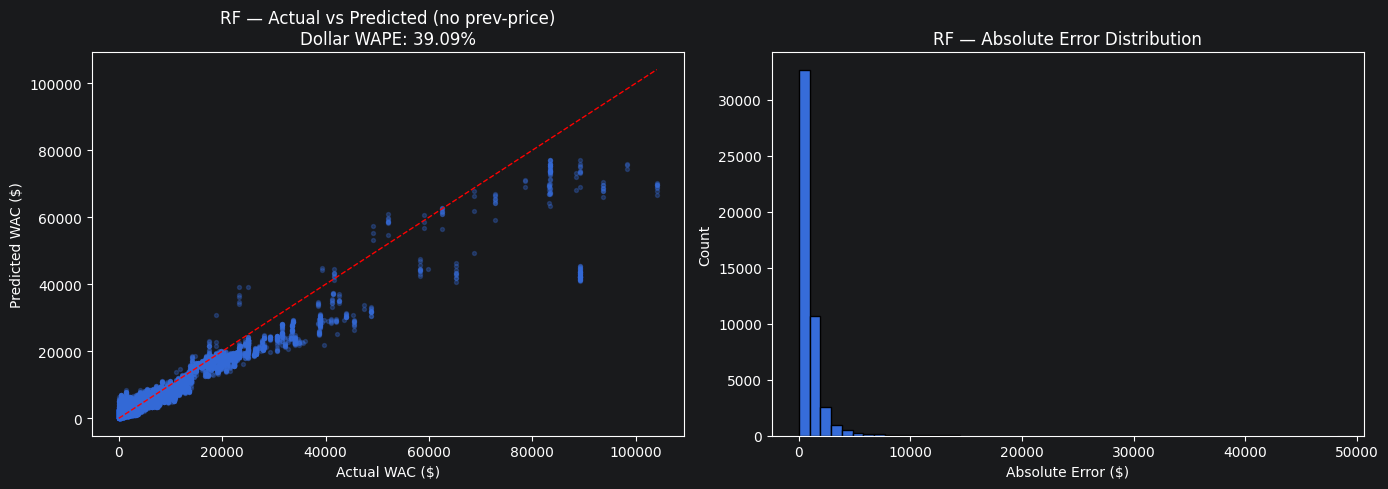

In [9]:
# ── RF — One-shot validation set evaluation ──
y_rf_pred = rf.predict(X_val)

rf_wape = np.sum(np.abs(y_val.values - y_rf_pred)) / np.sum(np.abs(y_val.values))
rf_mae  = np.mean(np.abs(y_val.values - y_rf_pred))
rf_med  = np.median(np.abs(y_val.values - y_rf_pred))
print(f'RF  Dollar WAPE : {rf_wape*100:.2f}%')
print(f'RF  Mean   MAE  : ${rf_mae:,.2f}')
print(f'RF  Median MAE  : ${rf_med:,.2f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_val, y_rf_pred, alpha=0.3, s=8)
axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=1)
axes[0].set_xlabel('Actual WAC ($)'); axes[0].set_ylabel('Predicted WAC ($)')
axes[0].set_title(f'RF — Actual vs Predicted (no prev-price)\nDollar WAPE: {rf_wape*100:.2f}%')
axes[1].hist(np.abs(y_val.values - y_rf_pred), bins=50, edgecolor='black')
axes[1].set_xlabel('Absolute Error ($)'); axes[1].set_ylabel('Count')
axes[1].set_title('RF — Absolute Error Distribution')
plt.tight_layout(); plt.show()


In [10]:
# ── GBT Regressor — CV Grid Search ──
param_grid = {
    'max_iter':         [200, 500],
    'max_depth':        [4, 5],
    'learning_rate':    [0.01, 0.05],
    'min_samples_leaf': [20, 50],
}

cv_results = []
for max_iter, max_depth, lr, msl in itertools.product(
        param_grid['max_iter'], param_grid['max_depth'],
        param_grid['learning_rate'], param_grid['min_samples_leaf']):
    model = HistGradientBoostingRegressor(
        max_iter=max_iter, max_depth=max_depth,
        learning_rate=lr, min_samples_leaf=msl, random_state=42
    )
    scores = cross_val_score(model, X_train, y_train,
                              cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
    mae = -scores.mean()
    cv_results.append({
        'max_iter': max_iter, 'max_depth': max_depth,
        'learning_rate': lr, 'min_samples_leaf': msl,
        'CV_MAE': round(mae, 4), 'CV_MAE_std': round(scores.std(), 4)
    })
    print(f'  iter={max_iter}  depth={max_depth}  lr={lr}  msl={msl}  CV MAE={mae:.4f} ± {scores.std():.4f}')

cv_df = pd.DataFrame(cv_results).sort_values('CV_MAE')
print('\n── Grid Search Results ──')
print(cv_df.to_string(index=False))

best = cv_df.iloc[0]
best_max_iter    = int(best['max_iter'])
best_max_depth   = int(best['max_depth'])
best_lr          = float(best['learning_rate'])
best_msl         = int(best['min_samples_leaf'])
print(f'\nBest: iter={best_max_iter}, depth={best_max_depth}, lr={best_lr}, msl={best_msl}  (CV MAE={best["CV_MAE"]})')


  iter=200  depth=4  lr=0.01  msl=20  CV MAE=482.9590 ± 66.5361
  iter=200  depth=4  lr=0.01  msl=50  CV MAE=481.6661 ± 64.2306
  iter=200  depth=4  lr=0.05  msl=20  CV MAE=133.7120 ± 66.2129
  iter=200  depth=4  lr=0.05  msl=50  CV MAE=137.6452 ± 55.8698
  iter=200  depth=5  lr=0.01  msl=20  CV MAE=479.5999 ± 64.8596
  iter=200  depth=5  lr=0.01  msl=50  CV MAE=476.1088 ± 62.3973
  iter=200  depth=5  lr=0.05  msl=20  CV MAE=139.0968 ± 66.4789
  iter=200  depth=5  lr=0.05  msl=50  CV MAE=133.9779 ± 59.3033
  iter=500  depth=4  lr=0.01  msl=20  CV MAE=145.9645 ± 64.0848
  iter=500  depth=4  lr=0.01  msl=50  CV MAE=150.6024 ± 57.2536
  iter=500  depth=4  lr=0.05  msl=20  CV MAE=133.6999 ± 66.0634
  iter=500  depth=4  lr=0.05  msl=50  CV MAE=139.4744 ± 55.9347
  iter=500  depth=5  lr=0.01  msl=20  CV MAE=147.7802 ± 62.9763
  iter=500  depth=5  lr=0.01  msl=50  CV MAE=146.5269 ± 58.4904
  iter=500  depth=5  lr=0.05  msl=20  CV MAE=139.2589 ± 66.7467
  iter=500  depth=5  lr=0.05  msl=50  CV

In [11]:
# ── GBT Regressor — fit with best CV params ──
gbt = HistGradientBoostingRegressor(
    max_iter=best_max_iter,
    max_depth=best_max_depth,
    learning_rate=best_lr,
    min_samples_leaf=best_msl,
    random_state=42
)
gbt.fit(X_train, y_train)
print(f'GBT trained (iter={best_max_iter}, depth={best_max_depth}, lr={best_lr}, msl={best_msl})')


GBT trained (iter=500, depth=4, lr=0.05, msl=20)


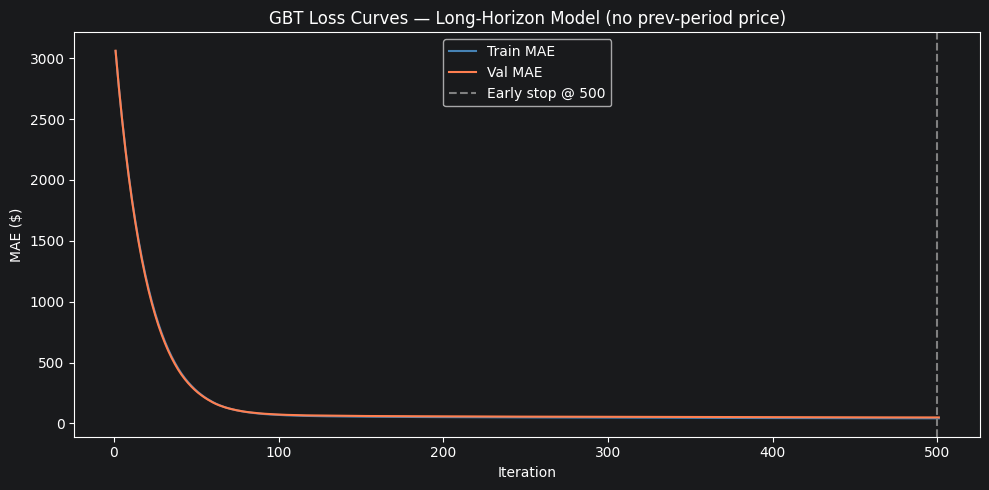

Train MAE: $41.94
Val   MAE: $49.41
Gap:       $7.47  (looks healthy)


In [12]:
# ── GBT — Loss curves to check overfitting ──
gbt_lc = HistGradientBoostingRegressor(
    max_iter=best_max_iter, max_depth=best_max_depth,
    learning_rate=best_lr, min_samples_leaf=best_msl,
    scoring='neg_mean_absolute_error',
    early_stopping=True, validation_fraction=0.15,
    n_iter_no_change=20, random_state=42
)
gbt_lc.fit(X_train, y_train)

iters = range(1, len(gbt_lc.train_score_) + 1)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(iters, -gbt_lc.train_score_, label='Train MAE',      color='steelblue', lw=1.5)
ax.plot(iters, -gbt_lc.validation_score_, label='Val MAE',   color='coral',     lw=1.5)
ax.axvline(gbt_lc.n_iter_, color='grey', linestyle='--', label=f'Early stop @ {gbt_lc.n_iter_}')
ax.set_xlabel('Iteration'); ax.set_ylabel('MAE ($)')
ax.set_title(f'GBT Loss Curves — Long-Horizon Model (no prev-period price)')
ax.legend(); plt.tight_layout(); plt.show()

gap = (-gbt_lc.validation_score_[-1]) - (-gbt_lc.train_score_[-1])
print(f'Train MAE: ${-gbt_lc.train_score_[-1]:,.2f}')
print(f'Val   MAE: ${-gbt_lc.validation_score_[-1]:,.2f}')
print(f'Gap:       ${gap:,.2f}  ({"likely overfitting" if gap > 500 else "looks healthy"})')


GBT Dollar WAPE : 3.85%
GBT Mean   MAE  : $97.71
GBT Median MAE  : $5.77


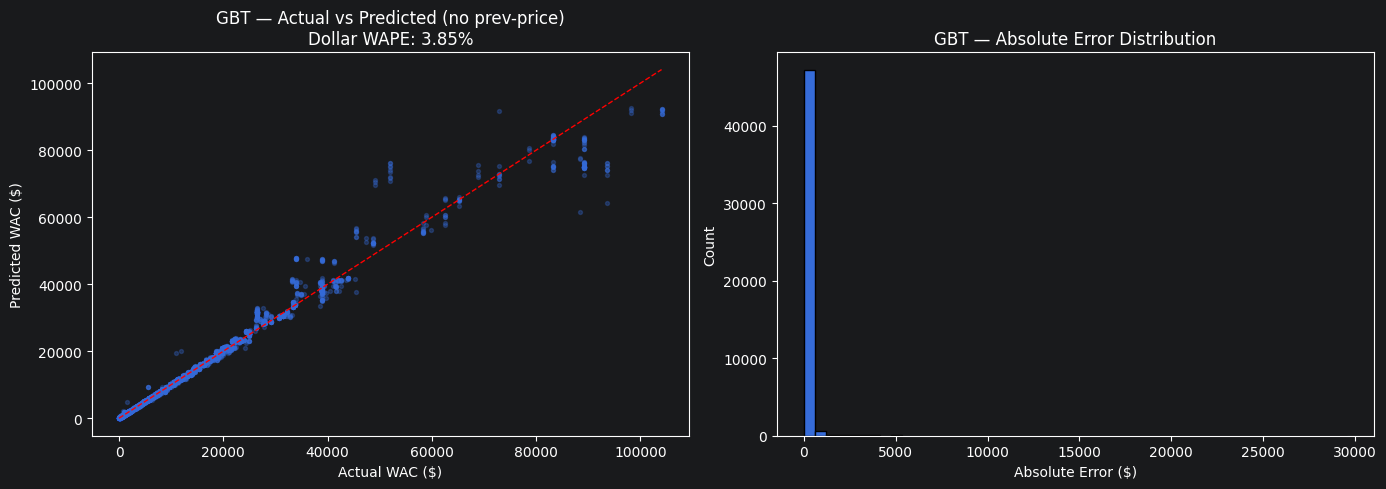

In [13]:
# ── GBT — One-shot validation set evaluation ──
y_gbt_pred = gbt.predict(X_val)

gbt_wape = np.sum(np.abs(y_val.values - y_gbt_pred)) / np.sum(np.abs(y_val.values))
gbt_mae  = np.mean(np.abs(y_val.values - y_gbt_pred))
gbt_med  = np.median(np.abs(y_val.values - y_gbt_pred))
print(f'GBT Dollar WAPE : {gbt_wape*100:.2f}%')
print(f'GBT Mean   MAE  : ${gbt_mae:,.2f}')
print(f'GBT Median MAE  : ${gbt_med:,.2f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_val, y_gbt_pred, alpha=0.3, s=8)
axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=1)
axes[0].set_xlabel('Actual WAC ($)'); axes[0].set_ylabel('Predicted WAC ($)')
axes[0].set_title(f'GBT — Actual vs Predicted (no prev-price)\nDollar WAPE: {gbt_wape*100:.2f}%')
axes[1].hist(np.abs(y_val.values - y_gbt_pred), bins=50, edgecolor='black')
axes[1].set_xlabel('Absolute Error ($)'); axes[1].set_ylabel('Count')
axes[1].set_title('GBT — Absolute Error Distribution')
plt.tight_layout(); plt.show()


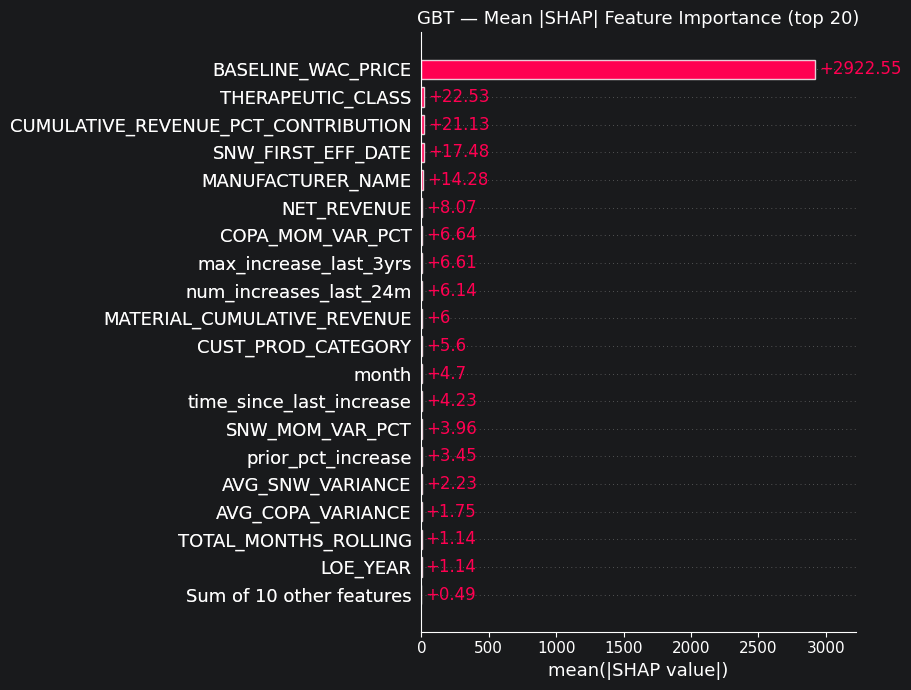

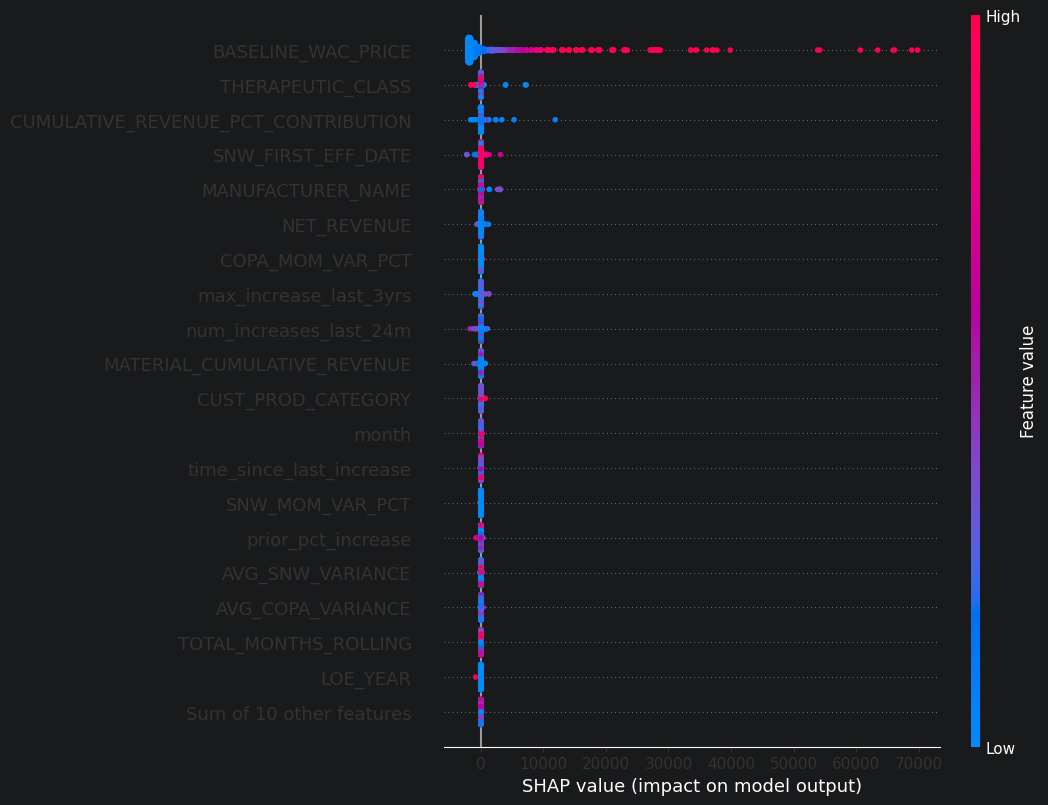

In [14]:
# ── SHAP Feature Importance — GBT Model ──
# Uses TreeExplainer on a sample of the validation set (fast for GBT).
# Shows: (1) mean |SHAP| bar chart, (2) beeswarm dot plot for value direction.
import shap

# Sample up to 2000 rows for speed (full val set can be slow)
sample_size = min(2000, len(X_val))
X_shap = X_val.sample(sample_size, random_state=42)

explainer   = shap.Explainer(gbt, X_shap)
shap_values = explainer(X_shap, check_additivity=False)

# ── Plot 1: Mean absolute SHAP — which features matter most ──
fig, ax = plt.subplots(figsize=(9, 7))
shap.plots.bar(shap_values, max_display=20, ax=ax, show=False)
ax.set_title("GBT — Mean |SHAP| Feature Importance (top 20)", fontsize=13)
plt.tight_layout()
plt.show()

# ── Plot 2: Beeswarm — direction of effect for top features ──
shap.plots.beeswarm(shap_values, max_display=20, show=True)


In [15]:
# ── Summary: Long-Horizon vs Short-Horizon comparison ──
# Short-horizon WAPE comes from Tree_based_modeling.ipynb (copy in manually after running that notebook)
short_horizon_rf_wape  = None  # e.g. 0.0230 — fill in from Tree_based_modeling RF result
short_horizon_gbt_wape = None  # e.g. 0.0180 — fill in from Tree_based_modeling GBT result

print('═' * 50)
print('Model Comparison — With vs Without PREV_PERIOD_BASELINE_WAC_PRICE')
print('═' * 50)
print(f'  RF  Long-Horizon  WAPE: {rf_wape*100:.2f}%')
print(f'  GBT Long-Horizon  WAPE: {gbt_wape*100:.2f}%')
if short_horizon_rf_wape:
    print(f'  RF  Short-Horizon WAPE: {short_horizon_rf_wape*100:.2f}%  (from Tree_based_modeling.ipynb)')
    print(f'  GBT Short-Horizon WAPE: {short_horizon_gbt_wape*100:.2f}%  (from Tree_based_modeling.ipynb)')
    print(f'  RF  degradation: +{(rf_wape - short_horizon_rf_wape)*100:.2f}pp')
    print(f'  GBT degradation: +{(gbt_wape - short_horizon_gbt_wape)*100:.2f}pp')
print('═' * 50)


══════════════════════════════════════════════════
Model Comparison — With vs Without PREV_PERIOD_BASELINE_WAC_PRICE
══════════════════════════════════════════════════
  RF  Long-Horizon  WAPE: 39.09%
  GBT Long-Horizon  WAPE: 3.85%
══════════════════════════════════════════════════


In [16]:
# ── Top-500 Revenue Products: data prep & WAPE computation ──
import matplotlib.cm as cm
from matplotlib.patches import Patch

top500 = pd.read_csv('~/PycharmProjects/JupyterProject/data/real_data/Top_500_revenueproducts.csv', dtype=str)
top500['ACTUAL_WAC']     = top500['ACTUAL_WAC'].astype(float)
top500['FORECASTED_WAC'] = top500['FORECASTED_WAC'].astype(float)
top500['REVENUE_RANK']   = top500['REVENUE_RANK'].astype(int)
top500 = top500[top500['RUN_ID'] == 'BT_2024_01'].copy()

mat_meta = (
    top500[['MTRL_NUM','MATERIAL_NAME','CUST_PROD_CATEGORY','REVENUE_RANK','THERAPEUTIC_CLASS','MANUFACTURER_NAME']]
    .sort_values('REVENUE_RANK').drop_duplicates(subset='MTRL_NUM').reset_index(drop=True)
)

# Build eval df from validation set — attach GBT and RF predictions
eval_df = reg_val_full.dropna(subset=['TGT_NEXT_MONTH_WAC']).copy().reset_index(drop=True)
eval_df['GBT_PREDICTED_WAC'] = y_gbt_pred
eval_df['RF_PREDICTED_WAC']  = y_rf_pred
eval_df['ACTUAL_WAC']        = y_val.values
eval_df['COPA_MTRL_NUM']     = eval_df['COPA_MTRL_NUM'].astype(str).str.zfill(18)
eval_df['WAC_PRICE_COPA_DATE'] = pd.to_datetime(eval_df['WAC_PRICE_COPA_DATE']).dt.strftime('%Y-%m-%d')

# Shift baseline FORECAST_MONTH back 1 month to align with model row date (T)
top500_join = top500[['MTRL_NUM','FORECAST_MONTH','FORECASTED_WAC']].copy()
top500_join['FORECAST_MONTH'] = (
    pd.to_datetime(top500_join['FORECAST_MONTH']) - pd.DateOffset(months=1)
).dt.strftime('%Y-%m-%d')
eval_df = eval_df.merge(
    top500_join.rename(columns={'MTRL_NUM':'COPA_MTRL_NUM','FORECAST_MONTH':'WAC_PRICE_COPA_DATE'}),
    on=['COPA_MTRL_NUM','WAC_PRICE_COPA_DATE'], how='inner'
)

print(f'Top-500 materials matched: {eval_df["COPA_MTRL_NUM"].nunique()} of {mat_meta.shape[0]}')
print(f'Material-month rows: {len(eval_df):,}')

def dollar_wape(actual, predicted):
    return np.sum(np.abs(actual - predicted)) / np.sum(np.abs(actual))

records = []
for mtrl, grp in eval_df.groupby('COPA_MTRL_NUM'):
    act  = grp['ACTUAL_WAC'].values
    records.append({
        'COPA_MTRL_NUM'        : mtrl,
        'GBT_DOLLAR_WAPE'      : dollar_wape(act, grp['GBT_PREDICTED_WAC'].values),
        'RF_DOLLAR_WAPE'       : dollar_wape(act, grp['RF_PREDICTED_WAC'].values),
        'BASELINE_DOLLAR_WAPE' : dollar_wape(act, grp['FORECASTED_WAC'].values),
        'N_MONTHS'             : len(grp),
    })

per_mat = (
    pd.DataFrame(records)
    .merge(mat_meta.rename(columns={'MTRL_NUM':'COPA_MTRL_NUM'}), on='COPA_MTRL_NUM')
    .sort_values('REVENUE_RANK').reset_index(drop=True)
)
per_mat['GBT_WAPE_IMPROVEMENT'] = per_mat['BASELINE_DOLLAR_WAPE'] - per_mat['GBT_DOLLAR_WAPE']
per_mat['RF_WAPE_IMPROVEMENT']  = per_mat['BASELINE_DOLLAR_WAPE'] - per_mat['RF_DOLLAR_WAPE']

overall_gbt  = dollar_wape(eval_df['ACTUAL_WAC'].values, eval_df['GBT_PREDICTED_WAC'].values)
overall_rf   = dollar_wape(eval_df['ACTUAL_WAC'].values, eval_df['RF_PREDICTED_WAC'].values)
overall_base = dollar_wape(eval_df['ACTUAL_WAC'].values, eval_df['FORECASTED_WAC'].values)
print(f'\nOverall Dollar WAPE — GBT Long-Horizon : {overall_gbt*100:.2f}%')
print(f'Overall Dollar WAPE — RF  Long-Horizon : {overall_rf*100:.2f}%')
print(f'Overall Dollar WAPE — Baseline         : {overall_base*100:.2f}%')

# ── Summary table ──
print()
print('=' * 60)
print('TOP-500 PRODUCTS — LONG-HORIZON MODEL SUMMARY')
print('=' * 60)
summary = pd.DataFrame({
    'Model'           : ['GBT (Long-Horizon)', 'RF (Long-Horizon)', 'Baseline'],
    'Overall WAPE'    : [f'{overall_gbt*100:.2f}%', f'{overall_rf*100:.2f}%', f'{overall_base*100:.2f}%'],
    'Median WAPE'     : [
        f'{per_mat["GBT_DOLLAR_WAPE"].median()*100:.2f}%',
        f'{per_mat["RF_DOLLAR_WAPE"].median()*100:.2f}%',
        f'{per_mat["BASELINE_DOLLAR_WAPE"].median()*100:.2f}%',
    ],
    'Beats Baseline'  : [
        f'{(per_mat["GBT_DOLLAR_WAPE"] < per_mat["BASELINE_DOLLAR_WAPE"]).mean()*100:.1f}%',
        f'{(per_mat["RF_DOLLAR_WAPE"]  < per_mat["BASELINE_DOLLAR_WAPE"]).mean()*100:.1f}%',
        '—',
    ],
})
print(summary.to_string(index=False))
print('=' * 60)
print(f'Materials matched: {eval_df["COPA_MTRL_NUM"].nunique()} / {mat_meta.shape[0]}')
print()
print('Top 20 by revenue rank:')
print(per_mat[['REVENUE_RANK','MATERIAL_NAME','GBT_DOLLAR_WAPE','RF_DOLLAR_WAPE',
               'BASELINE_DOLLAR_WAPE','GBT_WAPE_IMPROVEMENT']].head(20)
      .rename(columns={'GBT_DOLLAR_WAPE':'GBT_WAPE','RF_DOLLAR_WAPE':'RF_WAPE',
                       'BASELINE_DOLLAR_WAPE':'BASE_WAPE','GBT_WAPE_IMPROVEMENT':'GBT_IMPRV'})
      .round(4).to_string(index=False))


Top-500 materials matched: 379 of 425
Material-month rows: 4,706

Overall Dollar WAPE — GBT Long-Horizon : 2.67%
Overall Dollar WAPE — RF  Long-Horizon : 25.72%
Overall Dollar WAPE — Baseline         : 3.25%

TOP-500 PRODUCTS — LONG-HORIZON MODEL SUMMARY
             Model Overall WAPE Median WAPE Beats Baseline
GBT (Long-Horizon)        2.67%       1.51%          49.6%
 RF (Long-Horizon)       25.72%      28.39%           6.1%
          Baseline        3.25%       1.96%              —
Materials matched: 379 / 425

Top 20 by revenue rank:
 REVENUE_RANK                  MATERIAL_NAME  GBT_WAPE  RF_WAPE  BASE_WAPE  GBT_IMPRV
            1     HUMIRA CF PEN 40MG/0.4ML 2    0.0184   0.0443     0.0776     0.0592
            2    ELIQUIS TAB 5MG          60    0.1500   3.2204     0.0575    -0.0925
            3       STELARA PFS 90MG/1.0ML 1    0.0380   0.2576     0.0039    -0.0341
            4    DUPIXENT INJ 300MG/2ML    2    0.0579   0.5842     0.0471    -0.0108
            5     SKYRIZI

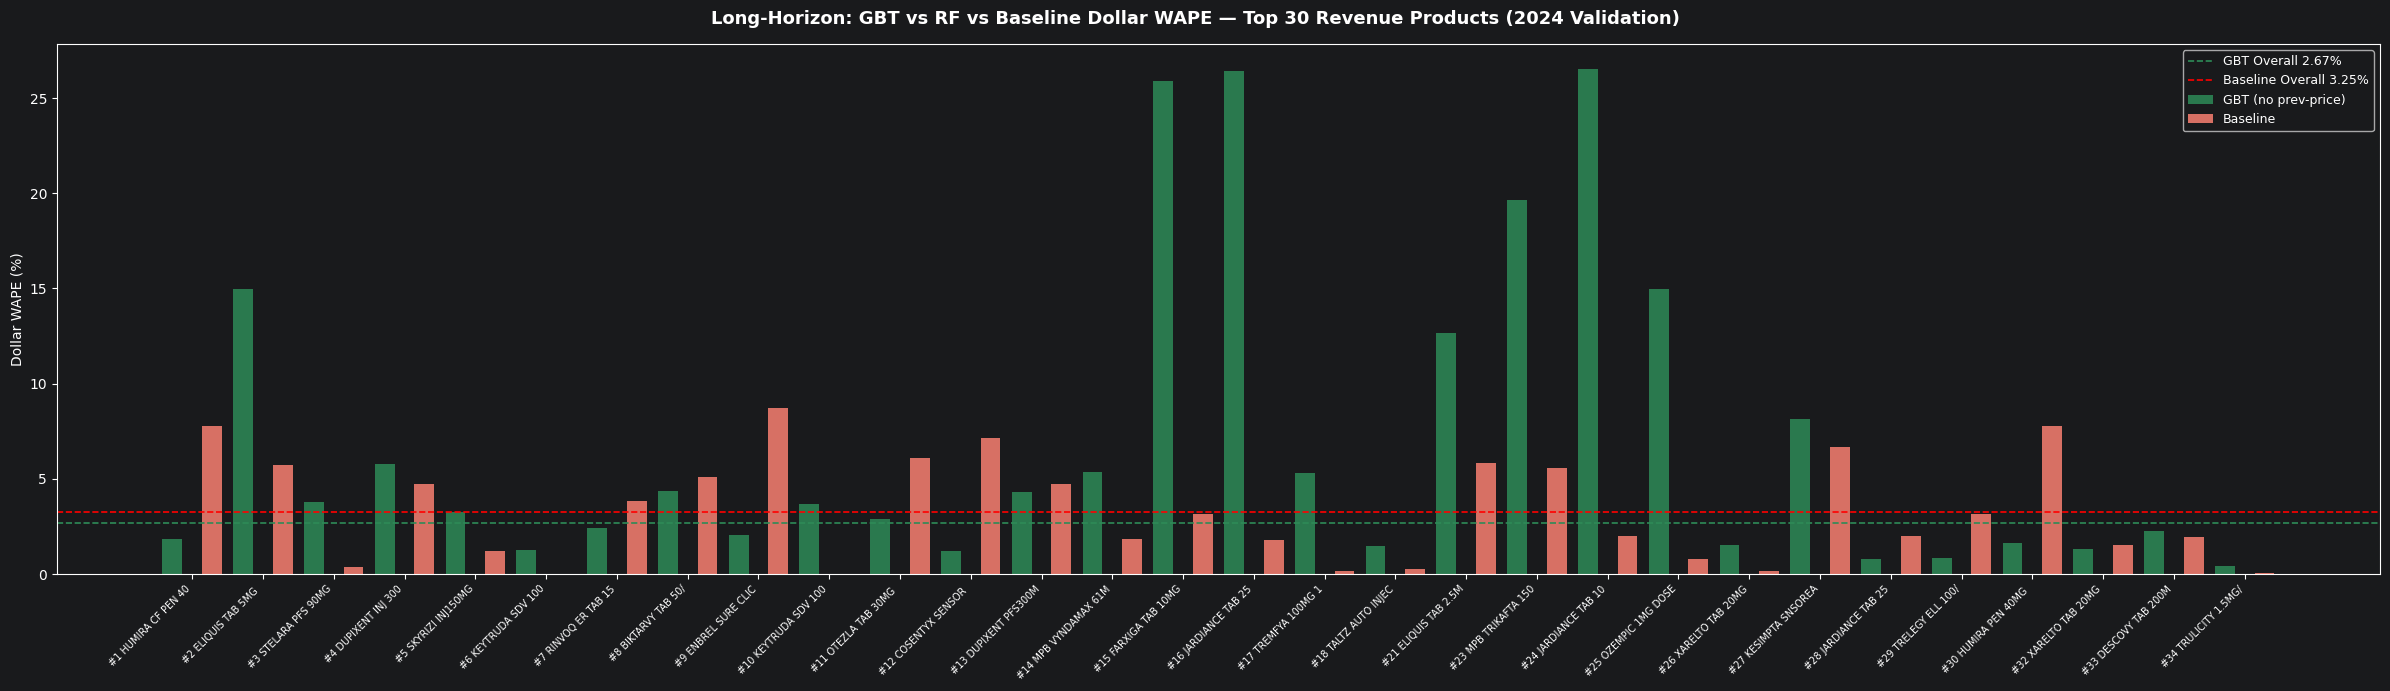

In [17]:
# ── Plot 1: Grouped bar — GBT vs RF vs Baseline Dollar WAPE (top 30) ──
top_n = per_mat.head(30).copy()
x     = np.arange(len(top_n))
w     = 0.28
cats       = per_mat['CUST_PROD_CATEGORY'].unique()
cat_colors = {c: cm.tab10(i/max(len(cats)-1,1)) for i, c in enumerate(sorted(cats))}

fig, ax = plt.subplots(figsize=(24, 7))
fig.suptitle('Long-Horizon: GBT vs RF vs Baseline Dollar WAPE — Top 30 Revenue Products (2024 Validation)',
             fontweight='bold', fontsize=13)
ax.bar(x - w,   top_n['GBT_DOLLAR_WAPE']*100,      w, label='GBT (no prev-price)', color='seagreen', alpha=0.85)
ax.bar(x + w,   top_n['BASELINE_DOLLAR_WAPE']*100,  w, label='Baseline',            color='salmon',    alpha=0.85)
ax.axhline(overall_gbt*100,  color='seagreen', linestyle='--', lw=1.2, label=f'GBT Overall {overall_gbt*100:.2f}%')
ax.axhline(overall_base*100, color='red',      linestyle='--', lw=1.2, label=f'Baseline Overall {overall_base*100:.2f}%')
ax.set_xticks(x)
ax.set_xticklabels(top_n.apply(lambda r: f"#{int(r['REVENUE_RANK'])} {r['MATERIAL_NAME'][:16]}", axis=1),
                   rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Dollar WAPE (%)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


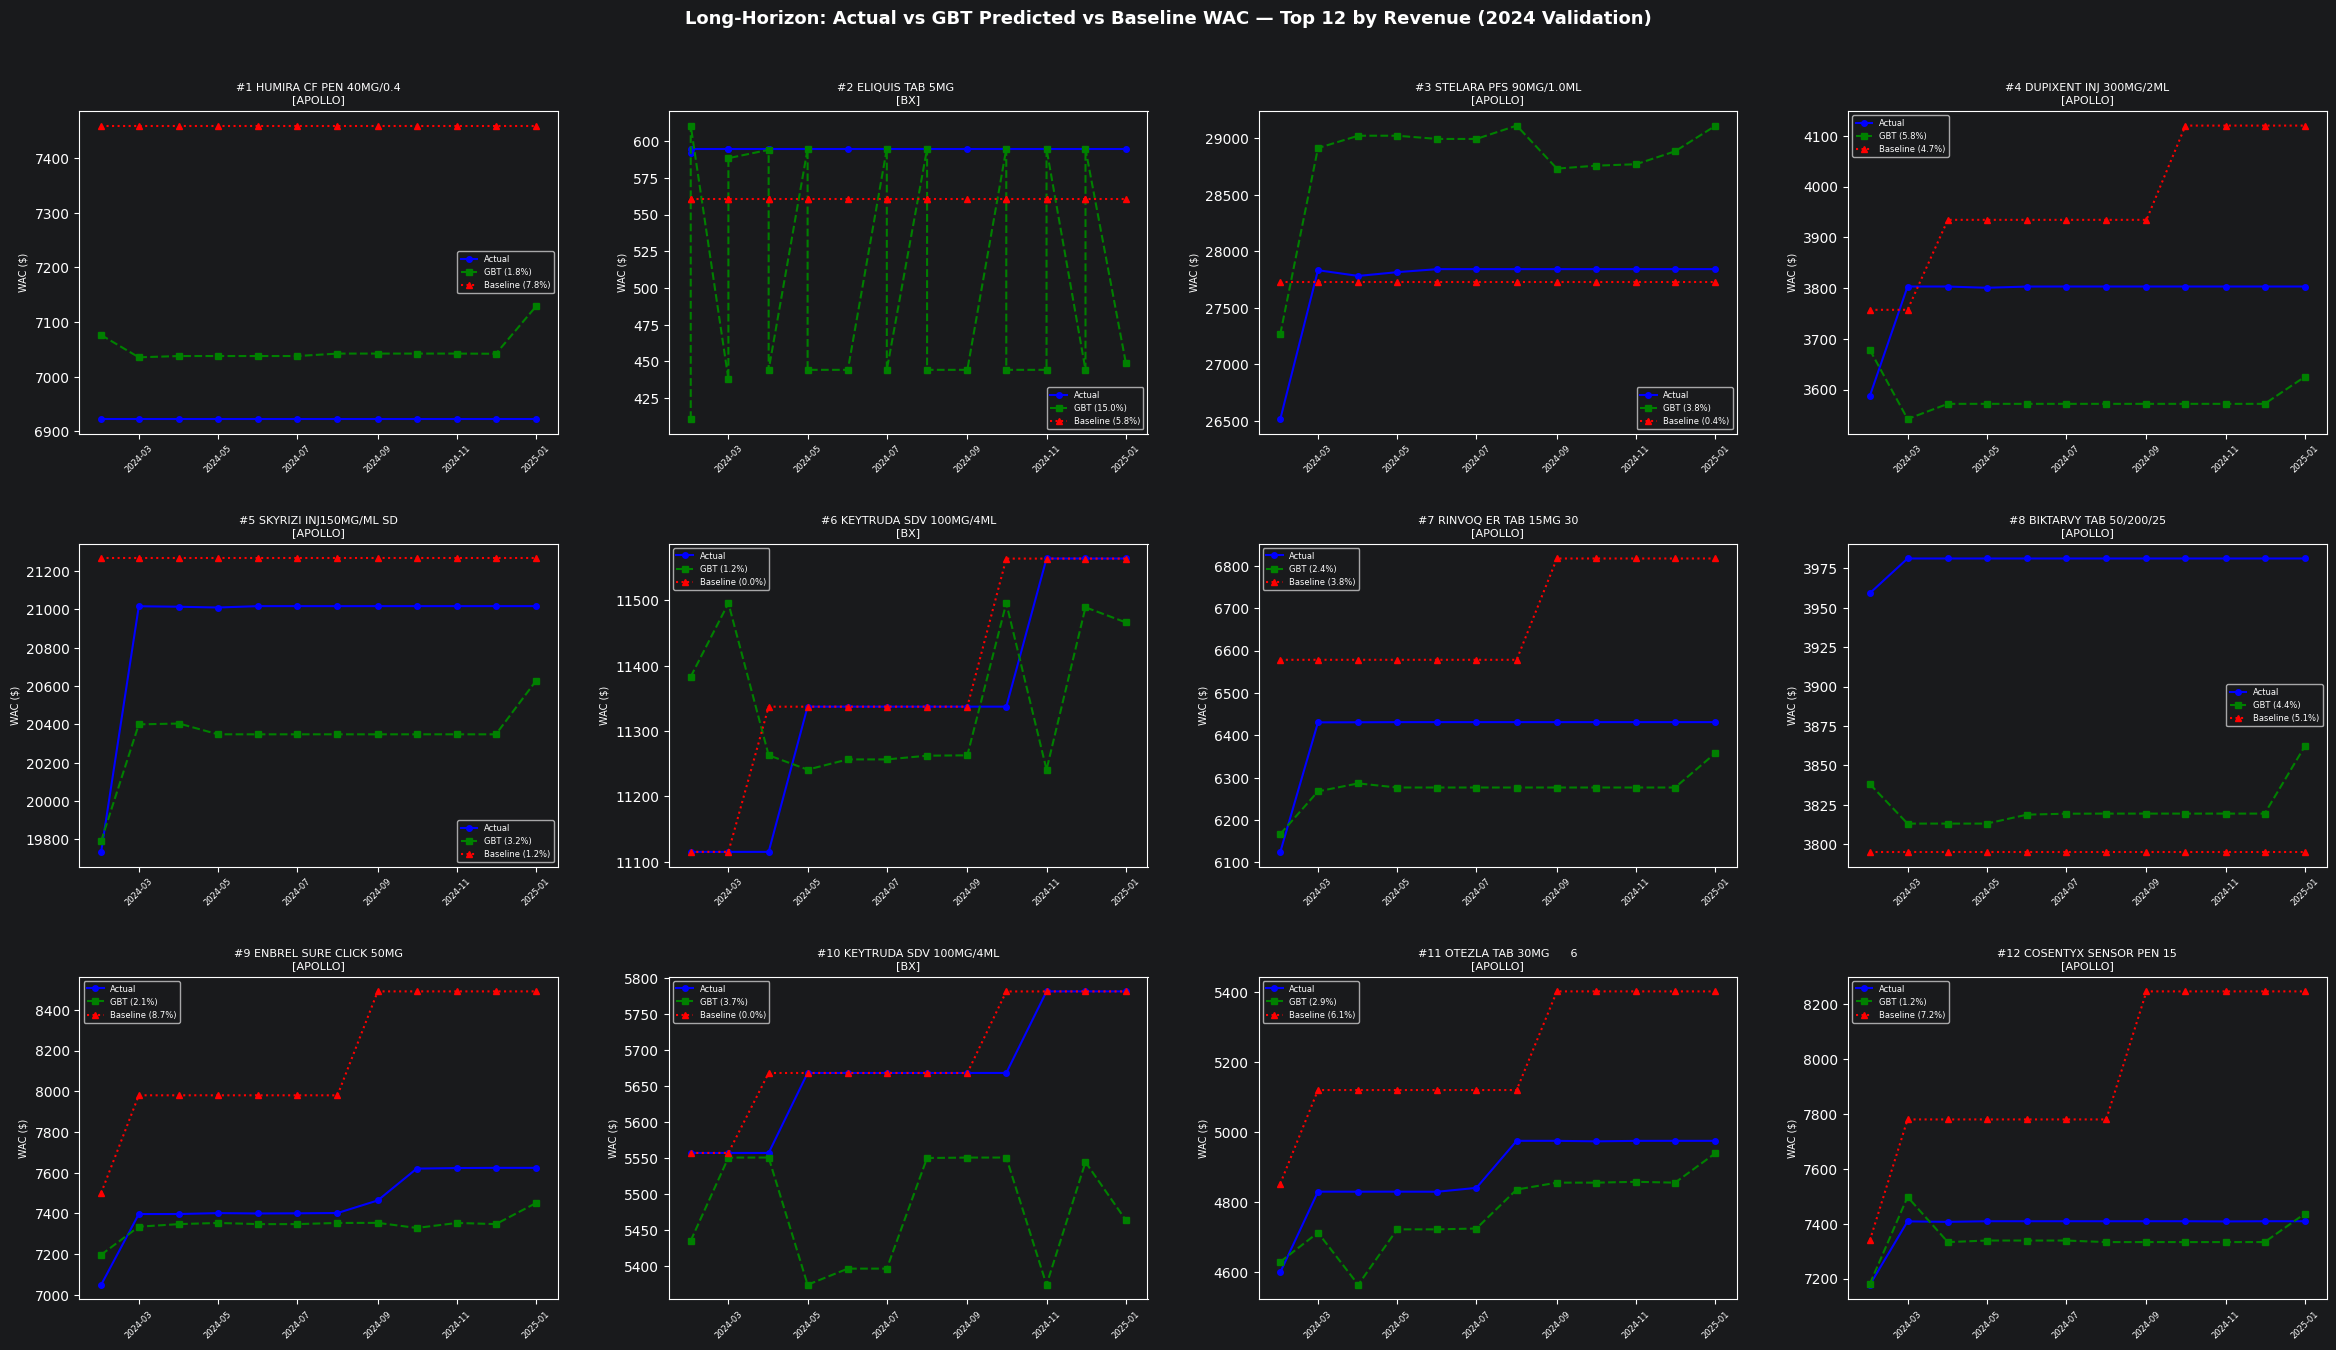

In [23]:
# ── Plot 2: Actual vs GBT vs Baseline time-series — top 12 by revenue ──
top12 = per_mat.head(12).reset_index(drop=True)
fig, axes = plt.subplots(3, 4, figsize=(24, 14))
fig.suptitle('Long-Horizon: Actual vs GBT Predicted vs Baseline WAC — Top 12 by Revenue (2024 Validation)',
             fontweight='bold', fontsize=13)
axes = axes.flatten()

for i, row in top12.iterrows():
    mtrl   = row['COPA_MTRL_NUM']
    subset = eval_df[eval_df['COPA_MTRL_NUM'] == mtrl].sort_values('WAC_PRICE_COPA_DATE')
    ax     = axes[i]
    dates  = pd.to_datetime(subset['WAC_PRICE_COPA_DATE']) + pd.DateOffset(months=1)
    ax.plot(dates, subset['BASELINE_WAC_PRICE'],          'b-o',  markersize=4, label='Actual')
    ax.plot(dates, subset['GBT_PREDICTED_WAC'],   'g--s', markersize=4, label=f"GBT ({row['GBT_DOLLAR_WAPE']*100:.1f}%)")
    ax.plot(dates, subset['FORECASTED_WAC'],       'r:^',  markersize=4, label=f"Baseline ({row['BASELINE_DOLLAR_WAPE']*100:.1f}%)")
    ax.set_title(f"#{int(row['REVENUE_RANK'])} {row['MATERIAL_NAME'][:22]}\n[{row['CUST_PROD_CATEGORY']}]", fontsize=8)
    ax.tick_params(axis='x', rotation=45, labelsize=6)
    ax.set_ylabel('WAC ($)', fontsize=7)
    ax.legend(fontsize=6)

plt.tight_layout(pad=3.0)
plt.show()


In [19]:
# ── Export predictions ──
out = reg_val_full[['COPA_MTRL_NUM', 'WAC_PRICE_COPA_DATE', 'BASELINE_WAC_PRICE',
                     'TGT_NEXT_MONTH_WAC']].copy()
out = out.dropna(subset=['TGT_NEXT_MONTH_WAC'])
out['RF_PRED_WAC']  = y_rf_pred
out['GBT_PRED_WAC'] = y_gbt_pred
out['RF_ABS_ERR']   = np.abs(out['TGT_NEXT_MONTH_WAC'] - out['RF_PRED_WAC'])
out['GBT_ABS_ERR']  = np.abs(out['TGT_NEXT_MONTH_WAC'] - out['GBT_PRED_WAC'])
out.to_csv('../data/real_data/long_horizon_predictions.csv', index=False)
print(f'Saved {len(out):,} rows → data/real_data/long_horizon_predictions.csv')


Saved 48,207 rows → data/real_data/long_horizon_predictions.csv


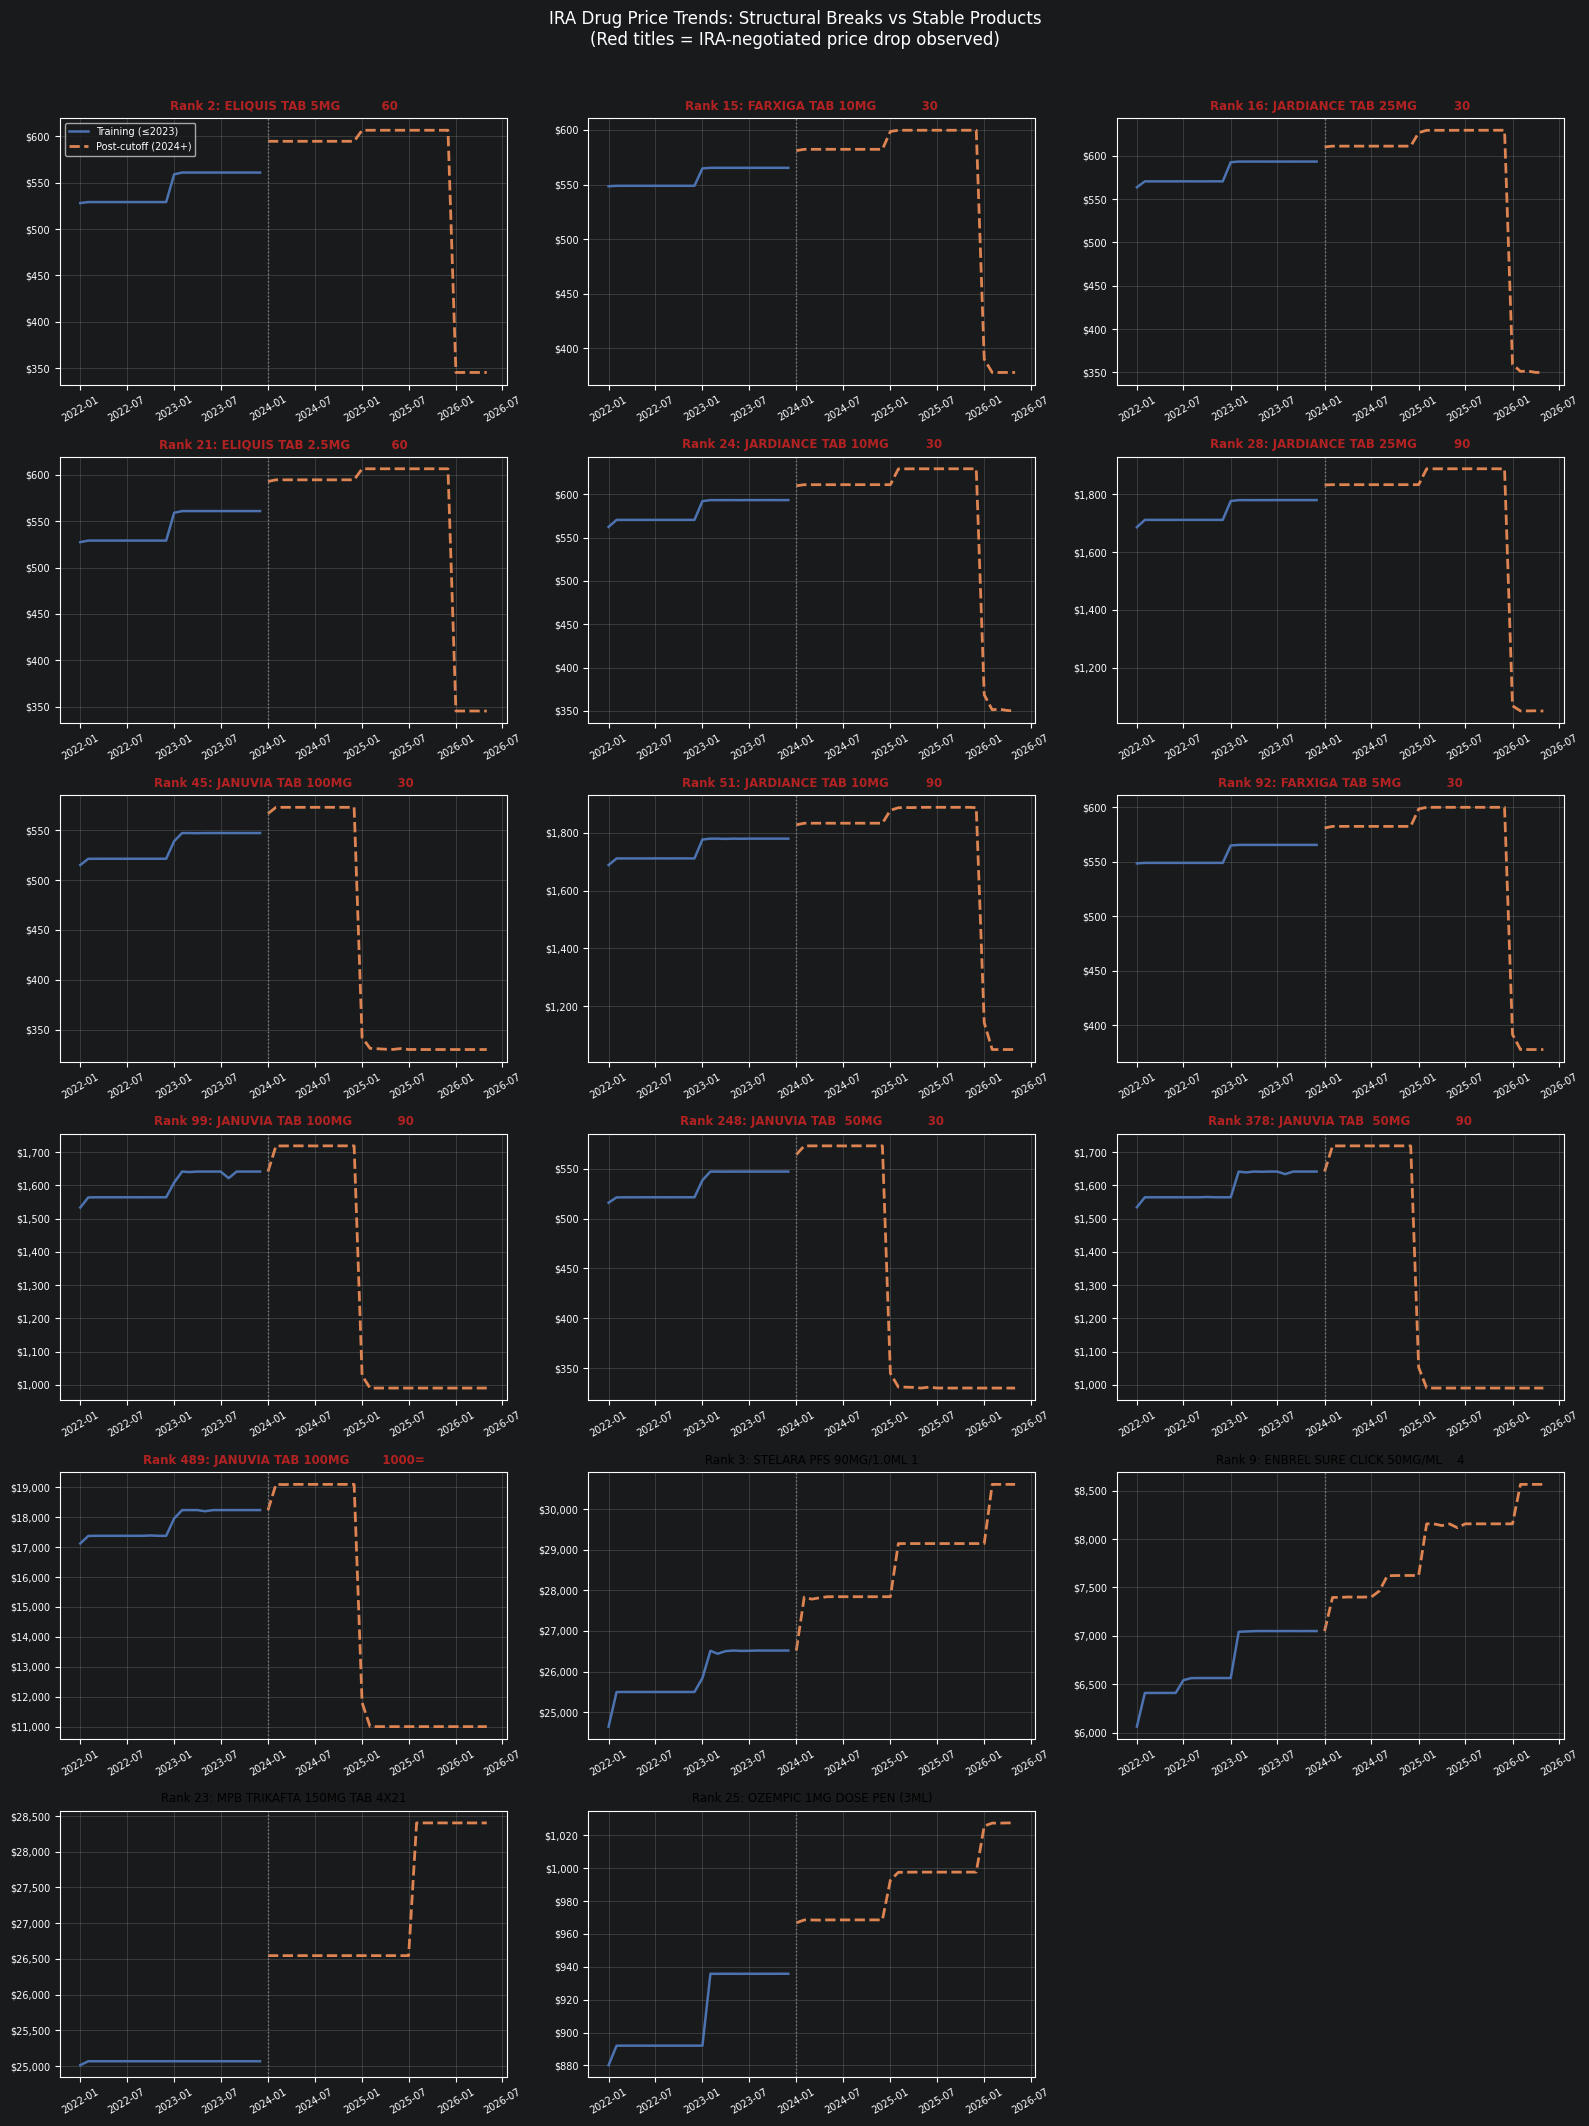

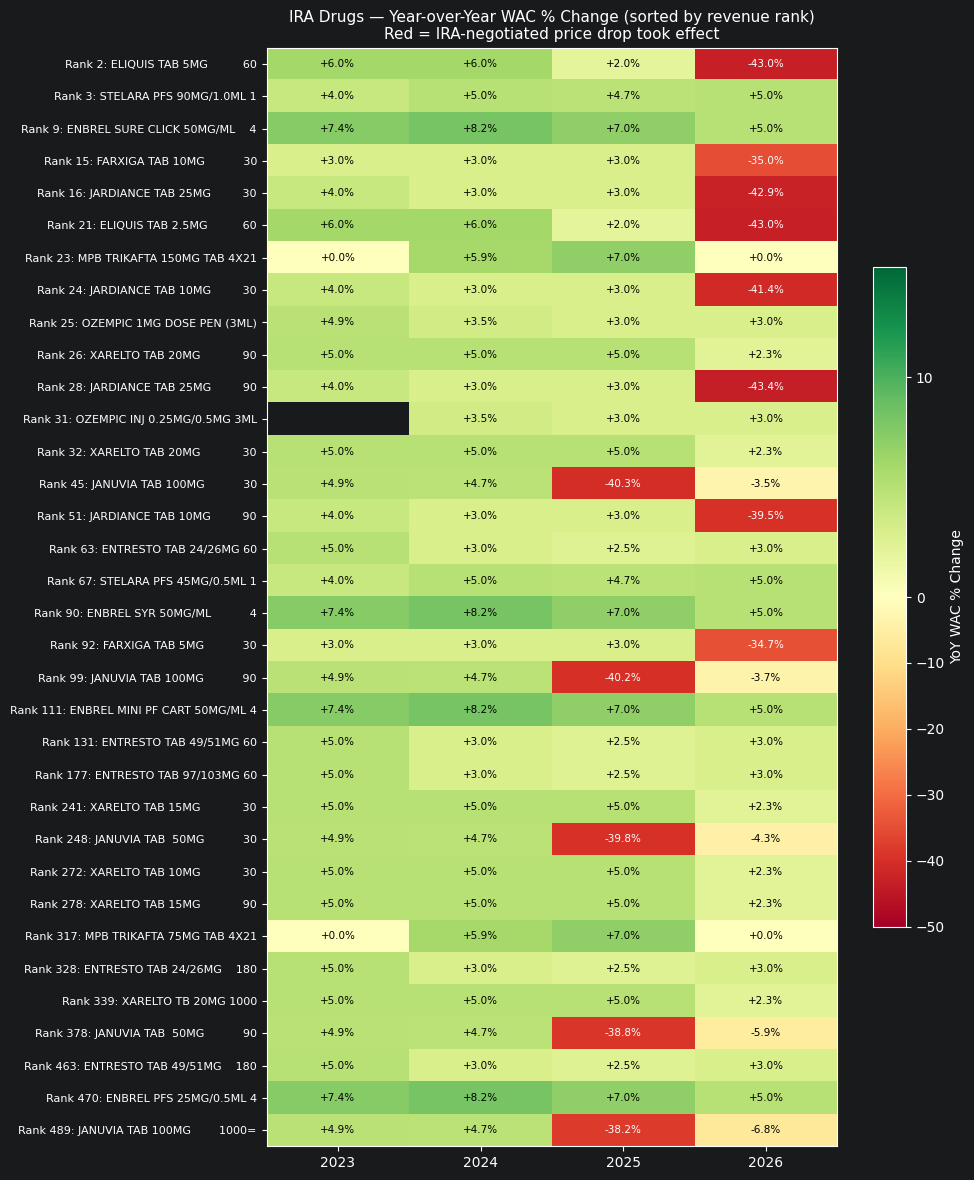


=== IRA STRUCTURAL BREAK SUMMARY ===
Material                                   Rank  2023→2024  2024→2025  2025→2026  Break?
-------------------------------------------------------------------------------------
ELIQUIS TAB 5MG          60                   2      +6.0%      +2.0%     -43.0%  ⚠ IRA DROP
STELARA PFS 90MG/1.0ML 1                      3      +5.0%      +4.7%      +5.0%  
ENBREL SURE CLICK 50MG/ML    4                9      +8.2%      +7.0%      +5.0%  
FARXIGA TAB 10MG           30                15      +3.0%      +3.0%     -35.0%  ⚠ IRA DROP
JARDIANCE TAB 25MG         30                16      +3.0%      +3.0%     -42.9%  ⚠ IRA DROP
ELIQUIS TAB 2.5MG          60                21      +6.0%      +2.0%     -43.0%  ⚠ IRA DROP
MPB TRIKAFTA 150MG TAB 4X21                  23      +5.9%      +7.0%      +0.0%  
JARDIANCE TAB 10MG         30                24      +3.0%      +3.0%     -41.4%  ⚠ IRA DROP
OZEMPIC 1MG DOSE PEN (3ML)                   25      +3.5%      +3.0%    

In [24]:
# ── IRA Drug Price Structural Breaks — Time Series Analysis ──
# Shows WAC price trends for IRA Round 1 negotiated drugs across 2022-2026.
# These drugs had government-negotiated prices take effect in 2025-2026,
# causing structural price drops that no ML model trained on 2022-2023 history can predict.
import matplotlib.patches as mpatches

ira_keywords = ["ELIQUIS", "JARDIANCE", "FARXIGA", "ENTRESTO", "ENBREL",
                "IMBRUVICA", "STELARA", "JANUVIA", "XARELTO", "OZEMPIC", "TRIKAFTA"]

top500_full = pd.read_csv("~/PycharmProjects/JupyterProject/data/real_data/Top_500_revenueproducts.csv")
top500_bt = top500_full[top500_full["RUN_ID"] == "BT_2024_01"]
ira_mtrls = (
    top500_bt[top500_bt["MATERIAL_NAME"].str.upper().apply(lambda x: any(k in x for k in ira_keywords))]
    [["REVENUE_RANK","MATERIAL_NAME","MTRL_NUM"]]
    .drop_duplicates("MTRL_NUM")
    .sort_values("REVENUE_RANK")
)

copa_full = pd.read_csv("~/PycharmProjects/JupyterProject/data/real_data/No_leakage_Active_COPA_data.csv")
copa_full["WAC_PRICE_COPA_DATE"] = pd.to_datetime(copa_full["WAC_PRICE_COPA_DATE"])
copa_full["COPA_MTRL_NUM_str"] = copa_full["COPA_MTRL_NUM"].astype(str).str.zfill(18)
ira_mtrl_strs = ira_mtrls["MTRL_NUM"].astype(str).str.zfill(18).tolist()

ira_copa = copa_full[copa_full["COPA_MTRL_NUM_str"].isin(ira_mtrl_strs)].merge(
    ira_mtrls[["MTRL_NUM","REVENUE_RANK","MATERIAL_NAME"]],
    left_on="COPA_MTRL_NUM", right_on="MTRL_NUM", how="left"
)

# ── Plot 1: Monthly price time series for top affected drugs ──
# Pick representative SKUs — one per drug family, top revenue rank
rep_drugs = (
    ira_copa.groupby("MATERIAL_NAME")["REVENUE_RANK"].min()
    .reset_index().sort_values("REVENUE_RANK")
)
# Flag drugs that had >10% drop in any single year (structural breaks)
annual = (ira_copa.groupby(["MATERIAL_NAME", ira_copa["WAC_PRICE_COPA_DATE"].dt.year])
          ["BASELINE_WAC_PRICE"].max().reset_index())
annual.columns = ["MATERIAL_NAME","YEAR","MAX_WAC"]
annual = annual.sort_values(["MATERIAL_NAME","YEAR"])
annual["YOY_PCT"] = annual.groupby("MATERIAL_NAME")["MAX_WAC"].pct_change() * 100
break_drugs = annual[annual["YOY_PCT"] < -10]["MATERIAL_NAME"].unique()
stable_drugs_sample = rep_drugs[~rep_drugs["MATERIAL_NAME"].isin(break_drugs)].head(4)["MATERIAL_NAME"].tolist()
break_drugs_top = rep_drugs[rep_drugs["MATERIAL_NAME"].isin(break_drugs)]["MATERIAL_NAME"].tolist()
plot_drugs = break_drugs_top + stable_drugs_sample  # breaks first, then stable comparisons

ncols = 3
nrows = -(-len(plot_drugs) // ncols)  # ceiling division
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()

train_cutoff = pd.Timestamp("2024-01-01")
colors = {"train": "#4C72B0", "val": "#DD8452"}

for idx, mat in enumerate(plot_drugs):
    ax = axes[idx]
    ts = (ira_copa[ira_copa["MATERIAL_NAME"] == mat]
          .groupby("WAC_PRICE_COPA_DATE")["BASELINE_WAC_PRICE"].max()
          .reset_index().sort_values("WAC_PRICE_COPA_DATE"))
    rank = ira_mtrls[ira_mtrls["MATERIAL_NAME"] == mat]["REVENUE_RANK"].values[0]
    is_break = mat in break_drugs

    train = ts[ts["WAC_PRICE_COPA_DATE"] < train_cutoff]
    val   = ts[ts["WAC_PRICE_COPA_DATE"] >= train_cutoff]

    ax.plot(train["WAC_PRICE_COPA_DATE"], train["BASELINE_WAC_PRICE"],
            color=colors["train"], linewidth=1.8, label="Training (≤2023)")
    ax.plot(val["WAC_PRICE_COPA_DATE"], val["BASELINE_WAC_PRICE"],
            color=colors["val"], linewidth=2.0, linestyle="--", label="Post-cutoff (2024+)")
    ax.axvline(train_cutoff, color="gray", linestyle=":", linewidth=1)

    title_color = "firebrick" if is_break else "black"
    ax.set_title(f"Rank {rank}: {mat[:30]}", fontsize=8.5, color=title_color, fontweight="bold" if is_break else "normal")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.tick_params(axis="x", labelsize=7, rotation=30)
    ax.tick_params(axis="y", labelsize=7)
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=7, loc="upper left")

# Hide unused axes
for ax in axes[len(plot_drugs):]:
    ax.set_visible(False)

fig.suptitle("IRA Drug Price Trends: Structural Breaks vs Stable Products\n"
             "(Red titles = IRA-negotiated price drop observed)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# ── Plot 2: YoY % change heatmap ──
yoy_table = annual[annual["YEAR"] >= 2023].pivot_table(
    index="MATERIAL_NAME", columns="YEAR", values="YOY_PCT"
).round(1)
yoy_table = yoy_table.loc[
    ira_copa.groupby("MATERIAL_NAME")["REVENUE_RANK"].min().sort_values().index
]
fig2, ax2 = plt.subplots(figsize=(10, max(6, len(yoy_table)*0.35)))
import matplotlib.colors as mcolors
cmap = plt.cm.RdYlGn
norm = mcolors.TwoSlopeNorm(vmin=-50, vcenter=0, vmax=15)
im = ax2.imshow(yoy_table.values, aspect="auto", cmap=cmap, norm=norm)
ax2.set_xticks(range(len(yoy_table.columns)))
ax2.set_xticklabels(yoy_table.columns.astype(int))
ax2.set_yticks(range(len(yoy_table.index)))
ax2.set_yticklabels([f"Rank {ira_copa.groupby('MATERIAL_NAME')['REVENUE_RANK'].min()[m]:.0f}: {m[:35]}"
                     for m in yoy_table.index], fontsize=8)
for i in range(len(yoy_table.index)):
    for j in range(len(yoy_table.columns)):
        val = yoy_table.values[i, j]
        if not np.isnan(val):
            ax2.text(j, i, f"{val:+.1f}%", ha="center", va="center", fontsize=7.5,
                     color="white" if abs(val) > 20 else "black")
plt.colorbar(im, ax=ax2, label="YoY WAC % Change", shrink=0.6)
ax2.set_title("IRA Drugs — Year-over-Year WAC % Change (sorted by revenue rank)\n"
              "Red = IRA-negotiated price drop took effect", fontsize=11)
plt.tight_layout()
plt.show()

# ── Summary table of structural breaks ──
print("\n=== IRA STRUCTURAL BREAK SUMMARY ===")
print(f"{'Material':<42} {'Rank':>4} {'2023→2024':>10} {'2024→2025':>10} {'2025→2026':>10}  Break?")
print("-" * 85)
for mat in yoy_table.index:
    r = int(ira_copa.groupby("MATERIAL_NAME")["REVENUE_RANK"].min()[mat])
    row = yoy_table.loc[mat]
    y24 = f"{row.get(2024, float('nan')):+.1f}%" if not np.isnan(row.get(2024, float('nan'))) else "  N/A"
    y25 = f"{row.get(2025, float('nan')):+.1f}%" if not np.isnan(row.get(2025, float('nan'))) else "  N/A"
    y26 = f"{row.get(2026, float('nan')):+.1f}%" if not np.isnan(row.get(2026, float('nan'))) else "  N/A"
    flag = "⚠ IRA DROP" if mat in break_drugs else ""
    print(f"{mat:<42} {r:>4} {y24:>10} {y25:>10} {y26:>10}  {flag}")


In [28]:
# ── Export 2026 WAC rows to Excel ──
copa_2026 = pd.read_csv("~/PycharmProjects/JupyterProject/data/real_data/No_leakage_Active_COPA_data.csv")
copa_2026["WAC_PRICE_COPA_DATE"] = pd.to_datetime(copa_2026["WAC_PRICE_COPA_DATE"])
copa_2026 = copa_2026[copa_2026["WAC_PRICE_COPA_DATE"].dt.year == 2026].copy()

# Add YoY % change vs same material in 2025
copa_all = pd.read_csv("~/PycharmProjects/JupyterProject/data/real_data/No_leakage_Active_COPA_data.csv")
copa_all["WAC_PRICE_COPA_DATE"] = pd.to_datetime(copa_all["WAC_PRICE_COPA_DATE"])

price_2025 = (copa_all[copa_all["WAC_PRICE_COPA_DATE"].dt.year == 2025]
              .groupby("COPA_MTRL_NUM")["BASELINE_WAC_PRICE"].max()
              .rename("MAX_WAC_2025"))
price_2024 = (copa_all[copa_all["WAC_PRICE_COPA_DATE"].dt.year == 2024]
              .groupby("COPA_MTRL_NUM")["BASELINE_WAC_PRICE"].max()
              .rename("MAX_WAC_2024"))

copa_2026 = copa_2026.merge(price_2025, on="COPA_MTRL_NUM", how="left")
copa_2026 = copa_2026.merge(price_2024, on="COPA_MTRL_NUM", how="left")
copa_2026["YOY_VS_2025_PCT"] = ((copa_2026["BASELINE_WAC_PRICE"] - copa_2026["MAX_WAC_2025"]) / copa_2026["MAX_WAC_2025"] * 100).round(2)
copa_2026["YOY_VS_2024_PCT"] = ((copa_2026["BASELINE_WAC_PRICE"] - copa_2026["MAX_WAC_2024"]) / copa_2026["MAX_WAC_2024"] * 100).round(2)

out_path = "~/PycharmProjects/JupyterProject/data/real_data/COPA_2026_WAC_Prices.xlsx"
copa_2026.to_excel(out_path, index=False)
print(f"Exported {len(copa_2026):,} rows to {out_path}")
print(f"Columns: {copa_2026.columns.tolist()}")
print(f"\nBiggest YoY drops vs 2025 (min per material):")
drops = (copa_2026.groupby("SELL_DSCR")["YOY_VS_2025_PCT"].min()
         .sort_values().head(15).reset_index())
drops.columns = ["SELL_DSCR", "MIN_YOY_VS_2025_PCT"]
print(drops.to_string(index=False))


Exported 29,291 rows to ~/PycharmProjects/JupyterProject/data/real_data/COPA_2026_WAC_Prices.xlsx
Columns: ['COPA_FISCAL_YEAR_PERIOD', 'WAC_PRICE_COPA_DATE', 'COPA_MTRL_NUM', 'COPA_NDC_NUM', 'COPA_WAC_PRICE', 'PREV_PERIOD_COPA_WAC_PRICE', 'CUST_PROD_CATEGORY', 'SNW_NDC_NUM', 'SNW_MTRL_NUM', 'SNW_FIRST_EFF_DATE', 'SNW_LAST_EFF_DATE', 'SNW_PRC_EFF_DT', 'SNW_WAC_PRICE', 'SELL_DSCR', 'NET_REVENUE', 'PREV_PERIOD_SNW_WAC_PRICE', 'COPA_SNW_WAC_PRICE_MATCH_IND', 'COPA_MOM_VAR_PCT', 'SNW_MOM_VAR_PCT', 'IS_FUTURE_PERIOD_FLAG', 'AVG_COPA_VARIANCE', 'AVG_SNW_VARIANCE', 'SNW_NULL_MONTHS_ROLLING', 'TOTAL_MONTHS_ROLLING', 'PREFERRED_SOURCE', 'EFFECTIVE_SOURCE', 'BASELINE_WAC_PRICE', 'PREV_PERIOD_BASELINE_WAC_PRICE', 'MATERIAL_CUMULATIVE_REVENUE', 'TOTAL_CUMULATIVE_REVENUE', 'BASELINE_MOM_VAR_PCT', 'CUMULATIVE_REVENUE_PCT_CONTRIBUTION', 'MAX_WAC_2025', 'MAX_WAC_2024', 'YOY_VS_2025_PCT', 'YOY_VS_2024_PCT']

Biggest YoY drops vs 2025 (min per material):
                     SELL_DSCR  MIN_YOY_VS_2025_PC

In [27]:
# ── Export 2026 WAC rows to Excel (Active_COPA_data_v2) ──
copa_v2 = pd.read_csv("~/PycharmProjects/JupyterProject/data/real_data/Active_COPA_data_v2.csv")
copa_v2["WAC_PRICE_COPA_DATE"] = pd.to_datetime(copa_v2["WAC_PRICE_COPA_DATE"])

# SELL_DSCR not in v2 — join from original dataset
copa_orig = pd.read_csv("~/PycharmProjects/JupyterProject/data/real_data/No_leakage_Active_COPA_data.csv",
                        usecols=["COPA_MTRL_NUM", "SELL_DSCR"]).drop_duplicates("COPA_MTRL_NUM")
copa_v2 = copa_v2.merge(copa_orig, on="COPA_MTRL_NUM", how="left")

copa_2026 = copa_v2[copa_v2["WAC_PRICE_COPA_DATE"].dt.year == 2026].copy()

price_2025 = (copa_v2[copa_v2["WAC_PRICE_COPA_DATE"].dt.year == 2025]
              .groupby("COPA_MTRL_NUM")["BASELINE_WAC_PRICE"].max()
              .rename("MAX_WAC_2025"))
price_2024 = (copa_v2[copa_v2["WAC_PRICE_COPA_DATE"].dt.year == 2024]
              .groupby("COPA_MTRL_NUM")["BASELINE_WAC_PRICE"].max()
              .rename("MAX_WAC_2024"))

copa_2026 = copa_2026.merge(price_2025, on="COPA_MTRL_NUM", how="left")
copa_2026 = copa_2026.merge(price_2024, on="COPA_MTRL_NUM", how="left")
copa_2026["YOY_VS_2025_PCT"] = ((copa_2026["BASELINE_WAC_PRICE"] - copa_2026["MAX_WAC_2025"]) / copa_2026["MAX_WAC_2025"] * 100).round(2)
copa_2026["YOY_VS_2024_PCT"] = ((copa_2026["BASELINE_WAC_PRICE"] - copa_2026["MAX_WAC_2024"]) / copa_2026["MAX_WAC_2024"] * 100).round(2)

out_path = "~/PycharmProjects/JupyterProject/data/real_data/COPA_v2_2026_WAC_Prices.xlsx"
copa_2026.to_excel(out_path, index=False)
print(f"Exported {len(copa_2026):,} rows to {out_path}")

print(f"\nBiggest YoY drops vs 2025 (min per material):")
drops = (copa_2026.groupby("SELL_DSCR")["YOY_VS_2025_PCT"].min()
         .sort_values().head(15).reset_index())
drops.columns = ["SELL_DSCR", "MIN_YOY_VS_2025_PCT"]
print(drops.to_string(index=False))


Exported 73,294 rows to ~/PycharmProjects/JupyterProject/data/real_data/COPA_v2_2026_WAC_Prices.xlsx

Biggest YoY drops vs 2025 (min per material):
                     SELL_DSCR  MIN_YOY_VS_2025_PCT
 BD SFTYGLIDE NDL 23G 1.5IN 50               -90.00
 CEREBYX 100MG/2ML PFIZ25 NOV+               -88.81
ACETADOTE IV 6G/30ML NO-EDTA 4               -88.66
  PPX VASOSTRICT VL 20UN/ML 25               -87.75
      VASOSTRICT VIAL 1ML X 25               -87.75
       WEZLANA VL 130MG/26ML 1               -85.89
  MPB CIMERLI 0.5MG/0.05ML SDV               -85.29
  MPB CIMERLI 0.3MG/0.05ML SDV               -85.29
      VASOSTRICT VL 20UN/ML 10               -84.07
  VASOSTRICT MDV 200UN/10ML  1               -84.07
VAS D5WDEXTROSESDV20UN/100ML10               -83.94
VASOSTRICT SDV40UNITS/100ML 10               -83.94
        PPX ERAXIS SDV 100MG 1               -81.35
  PPX TYGACIL INJ 50MG 10ML 10               -80.47
PAIN EASE MIST AERO CAN  3.9OZ               -79.41
